# 1. Preparación de Indicadores: Brechas de Victimización y Uso

Este notebook analiza el indicador:
- **DIMENSIÓN:** Género
- **VARIABLE:** Brechas de victimización y uso
- **INDICADOR:** % de encuestados que reportan incidentes de violencia digital, desagregado por sexo.
- **FUENTE:** Estudiantes
- **OBSERVACIONES:** Analiza si el sexo influye en la frecuencia de uso y en el tipo de riesgo digital experimentado.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)


## 1.1 Carga de Datos y Definición de Columnas
Según el inventario, usamos la Pregunta 21 para Estudiantes.

In [2]:
# Cargamos los datos de Estudiantes
df_estudiantes = pd.read_excel('../raw_data/BBDD_Estudiantes_dash.xlsx')

# Identificamos las columnas del inventario
col_genero = 'D2. ¿Género?'
col_riesgo = '21. ¿Alguna vez recibiste comentarios sexualizados, burlas sobre tu cuerpo o tu apariencia a través de redes sociales o mensajes en internet?'
col_frecuencia = '2. ¿Con qué frecuencia usas internet en un día normal de semana?'

print("Columnas seleccionadas con éxito.")


Columnas seleccionadas con éxito.


## 1.2 Creación de Columnas de Análisis
Mantenemos la columna original y creamos un indicador numérico/categórico para facilitar Power BI.

In [3]:
# 1. Indicador de victimización digital (1 = Sí, 0 = No, NaN = Prefiero no responder)
def categorizar_riesgo(respuesta):
    if pd.isna(respuesta): return np.nan
    val = str(respuesta)
    if 'Si' in val: return 1
    elif 'No' in val: return 0
    else: return np.nan

df_estudiantes['ind_victimizacion_digital'] = df_estudiantes[col_riesgo].apply(categorizar_riesgo)

# 2. Limpieza de género
df_estudiantes['genero_clean'] = df_estudiantes[col_genero].replace({
    'No binario': 'Otro/NS/NR',
    'Prefiero no decirlo': 'Otro/NS/NR',
    ' ': np.nan
})

# 3. Limpieza de frecuencia de uso (agrupando respuestas atípicas)
def categorizar_frecuencia(val):
    val = str(val).lower()
    if '1 y 3' in val: return '1-3 horas'
    elif '3 y 6' in val: return '3-6 horas'
    elif 'menos de 1' in val: return '< 1 hora'
    elif pd.isna(val) or val == 'nan': return np.nan
    elif 'más de 6' in val or '10 horas' in val or '16 horas' in val or 'todo el dia' in val or 'todo el día' in val or '9 horas' in val or '7 o 5' in val or '5 y 7' in val or 'medio dia' in val: 
        return '> 6 horas'
    else:
        return 'Otros'

df_estudiantes['frecuencia_uso_clean'] = df_estudiantes[col_frecuencia].apply(categorizar_frecuencia)

# Mostramos el resultado conservando la original
df_estudiantes[[col_riesgo, 'ind_victimizacion_digital', 'genero_clean', 'frecuencia_uso_clean']].head()


,"21. ¿Alguna vez recibiste comentarios sexualizados, burlas sobre tu cuerpo o tu apariencia a través de redes sociales o mensajes en internet?",ind_victimizacion_digital,genero_clean,frecuencia_uso_clean
0,"No, nunca",0.0,Masculino,1-3 horas
1,"No, nunca",0.0,Femenino,> 6 horas
2,"No, nunca",0.0,Masculino,3-6 horas
3,"No, nunca",0.0,Femenino,< 1 hora
4,"Si, una o dos veces",1.0,Femenino,> 6 horas


## 1.3 Opciones de Gráficos (Intermedios)

/var/folders/07/nzk8tlhn6j3b68hbxybf2xgw0000gn/T/ipykernel_34134/3047927270.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=resumen_genero, x='genero_clean', y='ind_victimizacion_digital', palette='Blues_r')


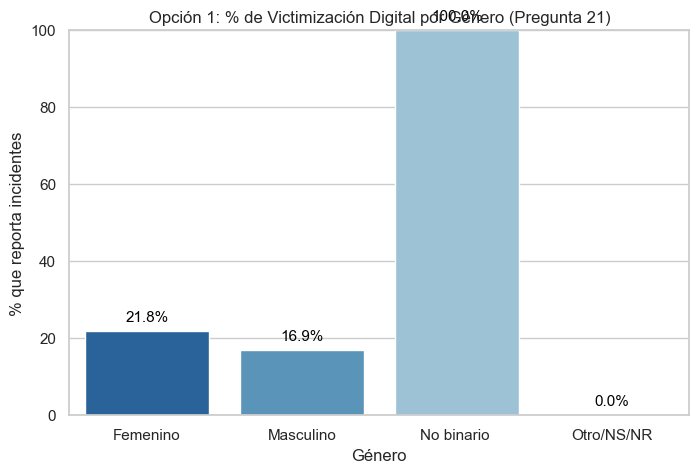

In [4]:
# Opción 1: Gráfico de Barras - % Victimización por Género
resumen_genero = df_estudiantes.dropna(subset=['ind_victimizacion_digital', 'genero_clean']).groupby('genero_clean')['ind_victimizacion_digital'].mean() * 100
resumen_genero = resumen_genero.reset_index()

plt.figure(figsize=(8, 5))
ax = sns.barplot(data=resumen_genero, x='genero_clean', y='ind_victimizacion_digital', palette='Blues_r')
plt.title('Opción 1: % de Victimización Digital por Género (Pregunta 21)')
plt.ylabel('% que reporta incidentes')
plt.xlabel('Género')
plt.ylim(0, 100)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=11, color='black', xytext=(0, 5), textcoords='offset points')

plt.show()


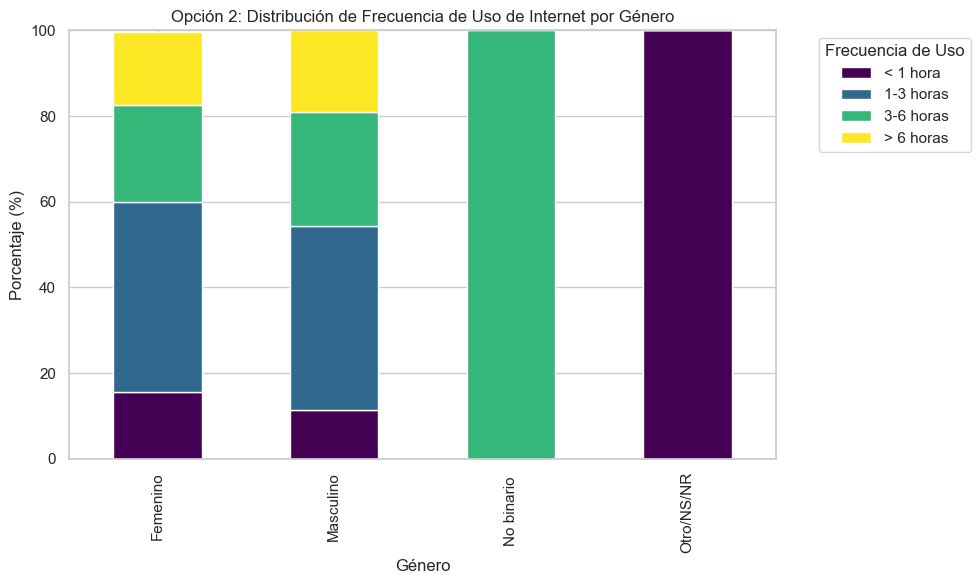

In [5]:
# Opción 2: Barras Apiladas 100% - Frecuencia de Uso vs Género
df_freq = df_estudiantes.dropna(subset=['frecuencia_uso_clean', 'genero_clean'])
freq_genero = pd.crosstab(df_freq['genero_clean'], df_freq['frecuencia_uso_clean'], normalize='index') * 100

freq_genero = freq_genero[['< 1 hora', '1-3 horas', '3-6 horas', '> 6 horas']]

freq_genero.plot(kind='bar', stacked=True, colormap='viridis', figsize=(10, 6))
plt.title('Opción 2: Distribución de Frecuencia de Uso de Internet por Género')
plt.ylabel('Porcentaje (%)')
plt.xlabel('Género')
plt.legend(title='Frecuencia de Uso', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


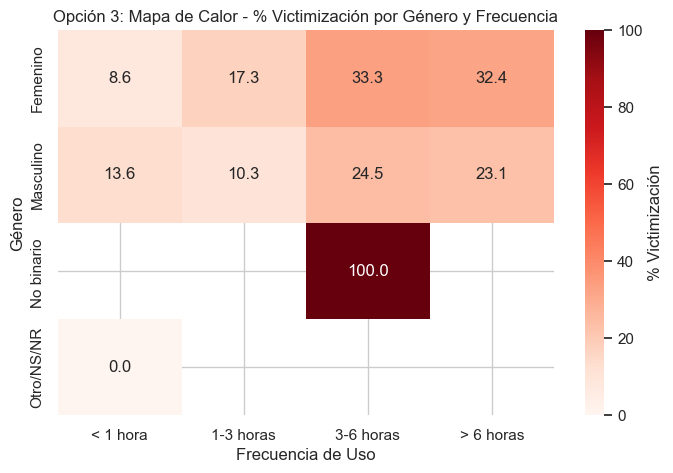

In [6]:
# Opción 3: Mapa de Calor - Riesgo, Frecuencia y Género
pivot = pd.pivot_table(
    df_estudiantes, 
    values='ind_victimizacion_digital', 
    index='genero_clean', 
    columns='frecuencia_uso_clean', 
    aggfunc='mean'
) * 100

# Ordenamos columnas lógicamente
pivot = pivot[['< 1 hora', '1-3 horas', '3-6 horas', '> 6 horas']]

plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="Reds", cbar_kws={'label': '% Victimización'})
plt.title('Opción 3: Mapa de Calor - % Victimización por Género y Frecuencia')
plt.ylabel('Género')
plt.xlabel('Frecuencia de Uso')
plt.show()


---
# 2. Preparación de Indicador: Violencia Digital Específica (CSEA)

Este análisis corresponde al indicador:
- **DIMENSIÓN:** Género
- **VARIABLE:** Violencia digital específica
- **INDICADOR:** Nivel de incidencia de presión para envío de fotos íntimas o comentarios sexualizados.
- **FUENTE:** Estudiantes
- **OBSERVACIONES:** Mide la prevalencia de conductas relacionadas con la CSEA (Explotación y Abuso Sexual Infantil en Línea).
- **PREGUNTA:** Pregunta 20


In [ ]:
# Identificamos la columna de la Pregunta 20
col_presion = '20. ¿Alguna vez sentiste presión para enviar fotos personales o íntimas a alguien por internet?'

# Función para categorizar la incidencia (1 = Sí sintió presión, 0 = No)
# Agrupamos todas las respuestas abiertas que indican 'Nunca', 'No' como 0.
def categorizar_presion(respuesta):
    if pd.isna(respuesta): return np.nan
    val = str(respuesta).lower()
    if 'si,' in val or 'sí,' in val or 'cedí' in val or 'negué' in val or 'más de una vez' in val:
        return 1
    elif 'no' in val or 'nunca' in val or 'jamás' in val:
        return 0
    else:
        # En caso de otras respuestas, las enviamos a NaN temporalmente
        return np.nan

df_estudiantes['ind_presion_fotos_intimas'] = df_estudiantes[col_presion].apply(categorizar_presion)

print("Valores originales de la Pregunta 20 vs Indicador creado:")
display(df_estudiantes[[col_presion, 'ind_presion_fotos_intimas']].value_counts(dropna=False))


In [ ]:
# Opción 1: Gráfico de Barras - % de Presión para envío de fotos íntimas por Género
resumen_presion = df_estudiantes.dropna(subset=['ind_presion_fotos_intimas', 'genero_clean']).groupby('genero_clean')['ind_presion_fotos_intimas'].mean() * 100
resumen_presion = resumen_presion.reset_index()

plt.figure(figsize=(8, 5))
ax = sns.barplot(data=resumen_presion, x='genero_clean', y='ind_presion_fotos_intimas', palette='flare')
plt.title('Opción 1: % de Incidencia de Presión para Enviar Fotos Íntimas por Género')
plt.ylabel('% que reporta presión')
plt.xlabel('Género')
plt.ylim(0, max(resumen_presion['ind_presion_fotos_intimas'].max() * 1.2, 20)) # Ajustamos el límite Y para ver bien las barras bajas

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=11, color='black', xytext=(0, 5), textcoords='offset points')

plt.show()


In [ ]:
# Opción 2: Tipos de respuestas afirmativas (Nivel de gravedad)
# Vamos a extraer sólo a quienes respondieron 'Sí' y ver qué pasó
df_si_presion = df_estudiantes[df_estudiantes[col_presion].astype(str).str.contains('Si,', na=False, case=False)]

plt.figure(figsize=(9, 5))
sns.countplot(data=df_si_presion, y=col_presion, hue='genero_clean', palette='viridis')
plt.title('Opción 2: Detalle de Respuestas Afirmativas por Género (Nivel de Gravedad)')
plt.xlabel('Cantidad de Estudiantes')
plt.ylabel('Respuesta Específica')
plt.legend(title='Género')
plt.tight_layout()
plt.show()
